# Monte Carlo Tree Search: From Random Darts to Game AI

Monte Carlo algorithms use randomness to solve problems that may be too large, too complex, or too expensive to solve exactly.

The name comes from the Monte Carlo casino because the method depends on repeated random trials. It became important in physics and weapons research, then spread to finance, graphics, planning, statistics, and game AI.

This notebook has two stages:

- **Stage 1: Monte Carlo pi**: estimate `pi` by throwing random darts at a square.
- **Stage 2: MCTS Tic-Tac-Toe**: build a small game AI that chooses moves by running many random playouts.

<details>
<summary>AlphaGo connection</summary>

AlphaGo could not search every possible Go future with minimax. Instead, it used Monte Carlo Tree Search with neural networks to focus on promising branches, simulate outcomes, and improve move choices statistically.

</details>

## 1. Why Monte Carlo?

Monte Carlo methods trade certainty for statistical evidence.

Instead of asking, "Can I inspect every future?" they ask:

```text
If I sample many possible futures, what pattern keeps showing up?
```

That is why Monte Carlo methods are useful for huge spaces: physics simulations, finance, graphics, planning, and game AI.

<details>
<summary>Minimax contrast</summary>

Minimax tries to reason over the whole game tree. MCTS samples the tree and spends more time on moves that look promising.

</details>

## 2. Stage 1: Estimate Pi With Random Darts

Draw a square from `-1` to `1` on both axes. Put a circle of radius `1` inside it.

If random darts land uniformly in the square:

```text
circle area / square area = pi / 4
```

So:

```text
pi ≈ 4 * inside_circle / total_darts
```

<details>
<summary>Sampling hint</summary>

A single dart tells you almost nothing. Thousands of darts reveal the area ratio.

</details>

**Trace model.** Define `Dart`, `PiEstimateStep`, the structure used to capture replayable algorithm state.


In [ ]:
from dataclasses import dataclass, field

from math import log, sqrt, inf

import random

import numpy as np

import matplotlib.pyplot as plt

@dataclass(frozen=True)
class Dart:
    x: float
    y: float
    inside_circle: bool

@dataclass(frozen=True)
class PiEstimateStep:
    darts_thrown: int
    inside_count: int
    pi_estimate: float


**Object model.** Define `MonteCarloPiEstimator`, the named objects used by the next examples.


In [ ]:
class MonteCarloPiEstimator:
    def __init__(self, seed: int = 42):
        self.rng = np.random.default_rng(seed)

    def throw_darts(self, total_darts: int, batch_size: int = 500) -> tuple[list[Dart], list[PiEstimateStep]]:
        darts: list[Dart] = []
        steps: list[PiEstimateStep] = []
        inside_count = 0
        thrown = 0

        while thrown < total_darts:
            current_batch = min(batch_size, total_darts - thrown)
            points = self.rng.uniform(-1, 1, size=(current_batch, 2))
            distances = points[:, 0] ** 2 + points[:, 1] ** 2
            inside_flags = distances <= 1

            for (x, y), inside in zip(points, inside_flags):
                darts.append(Dart(float(x), float(y), bool(inside)))

            inside_count += int(inside_flags.sum())
            thrown += current_batch
            steps.append(PiEstimateStep(thrown, inside_count, 4 * inside_count / thrown))

        return darts, steps


**Trace model.** Define `PiReplay`, the structure used to capture replayable algorithm state.


In [ ]:
class PiReplay:
    def __init__(self, steps: list[PiEstimateStep]):
        self.steps = steps

    def show(self, selected_counts: list[int]) -> None:
        by_count = {step.darts_thrown: step for step in self.steps}
        for count in selected_counts:
            step = by_count[count]
            error = abs(np.pi - step.pi_estimate)
            print(
                f"darts={step.darts_thrown:>5} inside={step.inside_count:>5} "
                f"pi≈{step.pi_estimate:.5f} error={error:.5f}"
            )

estimator = MonteCarloPiEstimator(seed=7)

darts, pi_steps = estimator.throw_darts(total_darts=5000, batch_size=500)

PiReplay(pi_steps).show([500, 1000, 2500, 5000])


## 3. Visualize the Darts

Inside-circle darts count toward the estimate. Outside-circle darts do not. More samples make the area ratio clearer.

<details>
<summary>Plot hint</summary>

The circle has radius `1`, centered at `(0, 0)`. Every dart with `x^2 + y^2 <= 1` lands inside it.

</details>

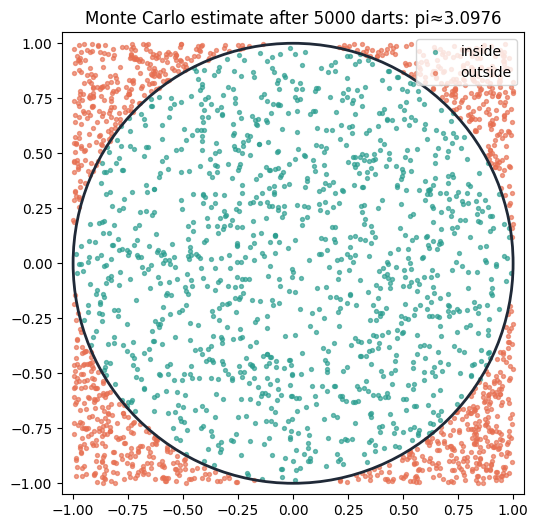

In [2]:
inside_x = [dart.x for dart in darts if dart.inside_circle]
inside_y = [dart.y for dart in darts if dart.inside_circle]
outside_x = [dart.x for dart in darts if not dart.inside_circle]
outside_y = [dart.y for dart in darts if not dart.inside_circle]

circle = plt.Circle((0, 0), 1, fill=False, color="#1f2937", linewidth=2)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(inside_x[:1200], inside_y[:1200], s=8, color="#2a9d8f", alpha=0.65, label="inside")
ax.scatter(outside_x[:1200], outside_y[:1200], s=8, color="#e76f51", alpha=0.65, label="outside")
ax.add_patch(circle)
ax.set_aspect("equal")
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_title(f"Monte Carlo estimate after 5000 darts: pi≈{pi_steps[-1].pi_estimate:.4f}")
ax.legend(loc="upper right")
plt.show()

## 4. Stage 2: Monte Carlo Tree Search

MCTS repeats four phases:

1. **Selection**: walk down known tree nodes using UCB1.
2. **Expansion**: add one unexplored child move.
3. **Simulation**: play randomly until the game ends.
4. **Backpropagation**: send the result back up the path.

After many loops, choose the immediate move with the best visit/win evidence.

<details>
<summary>UCB1 intuition</summary>

UCB1 balances exploitation and exploration. It prefers moves with good win rates, but also gives a bonus to moves that have not been tried much.

</details>

## 5. Build the MCTS Objects

Implementation plan:

1. `TicTacToeBoard` stores a small game state.
2. `MCTSNode` stores visits, wins, children, and unexplored moves.
3. `MCTSIteration` records one search loop.
4. `MCTSBot` runs selection, expansion, simulation, and backpropagation.
5. `MCTSReplay` prints the tree's learning story.

<details>
<summary>Why Tic-Tac-Toe?</summary>

Tic-Tac-Toe is small enough to understand, but it still has turns, wins, draws, and branching choices, which makes it a clean MCTS sandbox.

</details>

**Example state.** Create `WIN_LINES`, the concrete values used in the next run.


In [ ]:
WIN_LINES = (
    (0, 1, 2),
    (3, 4, 5),
    (6, 7, 8),
    (0, 3, 6),
    (1, 4, 7),
    (2, 5, 8),
    (0, 4, 8),
    (2, 4, 6),
)


**Object model.** Define `TicTacToeBoard`, the named objects used by the next examples.


In [ ]:
@dataclass(frozen=True)
class TicTacToeBoard:
    cells: tuple[str, ...] = (" ", " ", " ", " ", " ", " ", " ", " ", " ")
    turn: str = "X"

    def available_moves(self) -> list[int]:
        return [index for index, marker in enumerate(self.cells) if marker == " "]

    def place(self, move: int) -> "TicTacToeBoard":
        if move not in self.available_moves():
            raise ValueError(f"Move {move + 1} is not available.")
        new_cells = list(self.cells)
        new_cells[move] = self.turn
        next_turn = "O" if self.turn == "X" else "X"
        return TicTacToeBoard(tuple(new_cells), next_turn)

    def winner(self) -> str | None:
        for first, second, third in WIN_LINES:
            marker = self.cells[first]
            if marker != " " and marker == self.cells[second] == self.cells[third]:
                return marker
        return None

    def is_full(self) -> bool:
        return " " not in self.cells

    def is_terminal(self) -> bool:
        return self.winner() is not None or self.is_full()

    def result_for(self, player: str) -> float:
        winner = self.winner()
        if winner == player:
            return 1.0
        if winner is None:
            return 0.5
        return 0.0

    def render(self) -> str:
        display_cells = [marker if marker != " " else "." for marker in self.cells]
        rows = [" | ".join(display_cells[start:start + 3]) for start in range(0, 9, 3)]
        return "\n---------\n".join(rows)


**Object model.** Define `MCTSNode`, the named objects used by the next examples.


In [ ]:
@dataclass
class MCTSNode:
    board: TicTacToeBoard
    parent: "MCTSNode | None" = None
    move: int | None = None
    visits: int = 0
    wins: float = 0.0
    children: dict[int, "MCTSNode"] = field(default_factory=dict)
    unexplored_moves: list[int] = field(default_factory=list)

    def __post_init__(self) -> None:
        if not self.unexplored_moves:
            self.unexplored_moves = self.board.available_moves()

    def is_fully_expanded(self) -> bool:
        return len(self.unexplored_moves) == 0

    def win_rate(self) -> float:
        return self.wins / self.visits if self.visits else 0.0

    def ucb1(self, exploration_weight: float) -> float:
        if self.visits == 0:
            return inf
        if self.parent is None or self.parent.visits == 0:
            return self.win_rate()
        return self.win_rate() + exploration_weight * sqrt(log(self.parent.visits) / self.visits)


**Object model.** Define `MCTSIteration`, the named objects used by the next examples.


In [ ]:
@dataclass(frozen=True)
class MCTSIteration:
    iteration: int
    selected_depth: int
    expanded_move: int | None
    playout_result: float
    path_moves: tuple[int, ...]
    root_summary: tuple[tuple[int, int, float], ...]


**Algorithm engine.** Define `MCTSBot`, the class that runs the main simulation or algorithm.


In [ ]:
class MCTSBot:
    def __init__(self, player: str = "O", simulations: int = 1200, exploration_weight: float = 1.4, seed: int = 9):
        self.player = player
        self.simulations = simulations
        self.exploration_weight = exploration_weight
        self.rng = random.Random(seed)
        self.iterations: list[MCTSIteration] = []

    def choose_move(self, board: TicTacToeBoard) -> tuple[int, MCTSNode, list[MCTSIteration]]:
        root = MCTSNode(board=board)
        self.iterations = []

        for iteration in range(1, self.simulations + 1):
            node, selected_depth = self._select(root)
            expanded_move = None

            if not node.board.is_terminal() and node.unexplored_moves:
                node = self._expand(node)
                expanded_move = node.move

            result = self._simulate(node.board)
            path_moves = self._backpropagate(node, result)

            if iteration in {1, 2, 3, 10, 50, 200, self.simulations}:
                self.iterations.append(
                    MCTSIteration(
                        iteration=iteration,
                        selected_depth=selected_depth,
                        expanded_move=expanded_move,
                        playout_result=result,
                        path_moves=tuple(move for move in path_moves if move is not None),
                        root_summary=self._root_summary(root),
                    )
                )

        best_child = max(root.children.values(), key=lambda child: (child.visits, child.win_rate()))
        return best_child.move, root, self.iterations

    def _select(self, node: MCTSNode) -> tuple[MCTSNode, int]:
        depth = 0
        while not node.board.is_terminal() and node.is_fully_expanded() and node.children:
            node = max(node.children.values(), key=lambda child: child.ucb1(self.exploration_weight))
            depth += 1
        return node, depth

    def _expand(self, node: MCTSNode) -> MCTSNode:
        move = self.rng.choice(node.unexplored_moves)
        node.unexplored_moves.remove(move)
        child_board = node.board.place(move)
        child = MCTSNode(board=child_board, parent=node, move=move)
        node.children[move] = child
        return child

    def _simulate(self, board: TicTacToeBoard) -> float:
        current = board
        while not current.is_terminal():
            move = self.rng.choice(current.available_moves())
            current = current.place(move)
        return current.result_for(self.player)

    def _backpropagate(self, node: MCTSNode, result: float) -> list[int | None]:
        path_moves: list[int | None] = []
        current: MCTSNode | None = node
        while current is not None:
            current.visits += 1
            current.wins += result
            path_moves.append(current.move)
            current = current.parent
        return list(reversed(path_moves))

    def _root_summary(self, root: MCTSNode) -> tuple[tuple[int, int, float], ...]:
        summary = []
        for move, child in sorted(root.children.items()):
            summary.append((move, child.visits, round(child.win_rate(), 3)))
        return tuple(summary)


## 6. Run MCTS on a Tic-Tac-Toe Position

The bot is `O`. Instead of searching every possible future perfectly, it runs many random playouts and trusts the move with the best statistical evidence.

<details>
<summary>Move numbering</summary>

Positions are `1` through `9`, left to right and top to bottom. The code stores them as `0` through `8`, so printed moves add `1`.

</details>

In [4]:
mcts_board = TicTacToeBoard((
    "X", " ", " ",
    " ", "O", " ",
    " ", " ", "X",
), turn="O")

mcts_bot = MCTSBot(player="O", simulations=1500, exploration_weight=1.4, seed=10)
best_move, root, mcts_steps = mcts_bot.choose_move(mcts_board)

print("Current board:")
print(mcts_board.render())
print(f"\nMCTS chooses position {best_move + 1}.")
print("\nRoot child statistics:")
for move, child in sorted(root.children.items(), key=lambda item: item[1].visits, reverse=True):
    print(f"  move {move + 1}: visits={child.visits:>4}, win_rate={child.win_rate():.3f}")

Current board:
X | . | .
---------
. | O | .
---------
. | . | X

MCTS chooses position 8.

Root child statistics:
  move 8: visits= 331, win_rate=0.819
  move 3: visits= 277, win_rate=0.798
  move 7: visits= 275, win_rate=0.798
  move 2: visits= 219, win_rate=0.769
  move 4: visits= 214, win_rate=0.766
  move 6: visits= 184, win_rate=0.761


## 7. Replay the Search Learning

MCTS does not know the best move immediately. It builds confidence as more simulations update the tree.

<details>
<summary>Reading the replay</summary>

A move with more visits has attracted more search attention. A high win rate means random playouts from that move often worked well for the bot.

</details>

In [5]:
class MCTSReplay:
    def __init__(self, iterations: list[MCTSIteration]):
        self.iterations = iterations

    def show(self) -> None:
        for step in self.iterations:
            expanded = step.expanded_move + 1 if step.expanded_move is not None else "none"
            path = " -> ".join(str(move + 1) for move in step.path_moves) or "root"
            print(f"Iteration {step.iteration}: expanded={expanded}, result={step.playout_result:.1f}, path={path}")
            if step.root_summary:
                summary = ", ".join(
                    f"move {move + 1}: {visits} visits/{win_rate:.2f} rate"
                    for move, visits, win_rate in step.root_summary
                )
                print(f"  root: {summary}")
            print()


MCTSReplay(mcts_steps).show()

Iteration 1: expanded=7, result=1.0, path=7
  root: move 7: 1 visits/1.00 rate

Iteration 2: expanded=3, result=0.0, path=3
  root: move 3: 1 visits/0.00 rate, move 7: 1 visits/1.00 rate

Iteration 3: expanded=4, result=0.5, path=4
  root: move 3: 1 visits/0.00 rate, move 4: 1 visits/0.50 rate, move 7: 1 visits/1.00 rate

Iteration 10: expanded=3, result=1.0, path=8 -> 3
  root: move 2: 1 visits/0.00 rate, move 3: 1 visits/0.00 rate, move 4: 2 visits/0.75 rate, move 6: 1 visits/0.00 rate, move 7: 2 visits/0.50 rate, move 8: 3 visits/1.00 rate

Iteration 50: expanded=2, result=0.0, path=6 -> 8 -> 2
  root: move 2: 7 visits/0.43 rate, move 3: 5 visits/0.10 rate, move 4: 10 visits/0.60 rate, move 6: 9 visits/0.44 rate, move 7: 10 visits/0.50 rate, move 8: 9 visits/0.56 rate

Iteration 200: expanded=8, result=0.0, path=7 -> 3 -> 8
  root: move 2: 24 visits/0.46 rate, move 3: 39 visits/0.61 rate, move 4: 27 visits/0.52 rate, move 6: 33 visits/0.56 rate, move 7: 34 visits/0.57 rate, move 8: 

## 8. Experiment: More Simulations, Better Confidence

Small simulation counts can be noisy. More simulations usually produce more stable move rankings.

<details>
<summary>Experiment hint</summary>

MCTS is statistical. It can make different choices with different seeds or low simulation counts, especially when moves are close in value.

</details>

In [6]:
for simulation_count in [25, 100, 500, 1500]:
    experiment_bot = MCTSBot(player="O", simulations=simulation_count, exploration_weight=1.4, seed=10)
    move, experiment_root, _ = experiment_bot.choose_move(mcts_board)
    chosen_child = experiment_root.children[move]
    print(
        f"simulations={simulation_count:>4} -> move {move + 1}, "
        f"visits={chosen_child.visits:>4}, win_rate={chosen_child.win_rate():.3f}"
    )

simulations=  25 -> move 4, visits=   7, win_rate=0.643
simulations= 100 -> move 8, visits=  20, win_rate=0.600
simulations= 500 -> move 7, visits= 113, win_rate=0.712
simulations=1500 -> move 8, visits= 331, win_rate=0.819


## 9. Play a Scripted Game With MCTS

The human uses a planned move list. The bot answers with MCTS each turn.

<details>
<summary>Why scripted?</summary>

A scripted game makes the notebook fully runnable from top to bottom while still showing how the bot responds to changing boards.

</details>

**Object model.** Define `MCTSGameTurn`, the named objects used by the next examples.


In [ ]:
@dataclass(frozen=True)
class MCTSGameTurn:
    actor: str
    move: int
    board: TicTacToeBoard
    note: str


**Object model.** Define `MCTSMatch`, the named objects used by the next examples.


In [ ]:
class MCTSMatch:
    def __init__(self, simulations_per_move: int = 800, seed: int = 30):
        self.simulations_per_move = simulations_per_move
        self.seed = seed

    def play_script(self, human_positions: list[int]) -> list[MCTSGameTurn]:
        board = TicTacToeBoard(turn="X")
        turns: list[MCTSGameTurn] = []
        bot_seed = self.seed

        for planned_position in human_positions:
            if board.is_terminal():
                break

            human_move = planned_position - 1
            if human_move not in board.available_moves():
                human_move = board.available_moves()[0]
            board = board.place(human_move)
            turns.append(MCTSGameTurn("Human X", human_move + 1, board, "planned move"))

            if board.is_terminal():
                break

            bot = MCTSBot(player="O", simulations=self.simulations_per_move, seed=bot_seed)
            bot_seed += 1
            bot_move, bot_root, _ = bot.choose_move(board)
            bot_child = bot_root.children[bot_move]
            board = board.place(bot_move)
            turns.append(
                MCTSGameTurn(
                    "MCTS O",
                    bot_move + 1,
                    board,
                    f"{bot_child.visits} visits, {bot_child.win_rate():.3f} win rate",
                )
            )

        return turns


**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
scripted_turns = MCTSMatch(simulations_per_move=900, seed=100).play_script([1, 9, 6, 7, 2])

for turn_number, turn in enumerate(scripted_turns, start=1):
    print(f"Turn {turn_number}: {turn.actor} chose {turn.move} ({turn.note})")
    print(turn.board.render())
    print()

final_board = scripted_turns[-1].board

winner = final_board.winner()

print("Result:", f"{winner} wins" if winner else "draw")


## What You Should Remember

Monte Carlo algorithms use random samples to estimate answers.

- Estimating `pi` shows the core idea: random samples can reveal deterministic structure.
- MCTS applies that idea to game trees.
- Selection uses UCB1 to balance promising moves and underexplored moves.
- Expansion adds a new child node.
- Simulation plays randomly to the end.
- Backpropagation updates visits and win totals.
- More simulations usually mean better confidence, not absolute certainty.

<details>
<summary>AlphaGo mental model</summary>

AlphaGo made MCTS stronger by using neural networks to guide which branches were promising and to evaluate positions. The tree search still used the same sampling-and-backpropagation heartbeat.

</details>

## Visual Trace + Rigor Studio

**Problem frame.** Search huge game trees by sampling promising branches.

**Interactive animation target.** Animate selection, expansion, rollout, and backpropagation with visit counts and win rates.

**Correctness handle.** Backpropagated statistics summarize all simulations that passed through a node.

**Complexity handle.** Budget-driven; cost is roughly playouts times rollout length.

**Failure mode to test.** Too few playouts can overfit noise; poor rollout policy can bias the estimates.

**Studio task.** Double the playout budget until the recommended move stabilizes.


In [ ]:
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "courseware").exists():
        sys.path.insert(0, str(candidate))
        break

from courseware import AlgorithmPlayer, AlgorithmTrace, TraceStep, render_trace_table

# Convert the implementation above into snapshots:
# trace = AlgorithmTrace("Topic trace")
# trace.append("start", {"your_state": ...}, "What changed?", invariant="What remains true?")
# AlgorithmPlayer(trace, your_renderer).display()
print("Use AlgorithmTrace to turn this notebook's algorithm into a step-by-step visual player.")
